# 1. Supervised Learning — Predicting Tweet Sentiment

**Scenario:** Same airline social-media story as the rest of the session. We have
300 real, public tweets about US airlines (from the well-known "Twitter US Airline
Sentiment" dataset), and each tweet is already **labeled** — a human has tagged it
positive, negative, or neutral.

That's exactly what makes this **supervised learning**: we have the "answer key"
(the label), and we train a model to predict that answer key for tweets it has
never seen before.

Run each cell top to bottom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)

df = pd.read_csv("../data/Tweets.csv")
print(f"Loaded {len(df)} tweets")
df.head()

Loaded 300 tweets


,text,airline_sentiment,airline
0,@virginamerica awesome deals DAL-AUS for only ...,positive,Virgin America
1,@united Was able to send the DM. All good now.,positive,United
2,@united Our vacation's going to be ruined w/ 3...,neutral,United
3,@united its funny how none of ur tweets back a...,negative,United
4,@united thank YOU for your kindness. Your agen...,positive,United


## Step 1 — Look at the labeled data

Notice: every row already has an `airline_sentiment` label. This is the "supervision"
— the model will learn the relationship between the tweet text and this label.

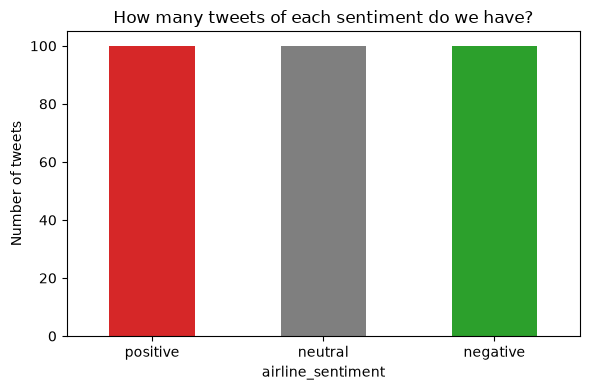

In [2]:
df["airline_sentiment"].value_counts().plot(
    kind="bar", color=["#d62728", "#7f7f7f", "#2ca02c"], figsize=(6, 4)
)
plt.title("How many tweets of each sentiment do we have?")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Step 2 — Split into training and test sets

We hide part of the labeled data (the **test set**) from the model during training,
so afterward we can honestly check: did it actually learn the pattern, or did it
just memorize?

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["airline_sentiment"], test_size=0.25, random_state=42, stratify=df["airline_sentiment"]
)
print(f"Training on {len(X_train)} tweets, testing on {len(X_test)} tweets")

Training on 225 tweets, testing on 75 tweets


## Step 3 — Turn text into numbers, then train

Models don't understand words directly — we convert each tweet into a vector of
word-importance scores (**TF-IDF**), then train a simple classifier
(**Logistic Regression**) to map those vectors to sentiment labels.

In [4]:
vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Model trained.")

Model trained.


## Step 4 — How well did it learn?

Accuracy on the **test set** (tweets the model never saw during training) tells us
how well this generalizes — this is the real test of learning, not memorization.

Test accuracy: 62.7%


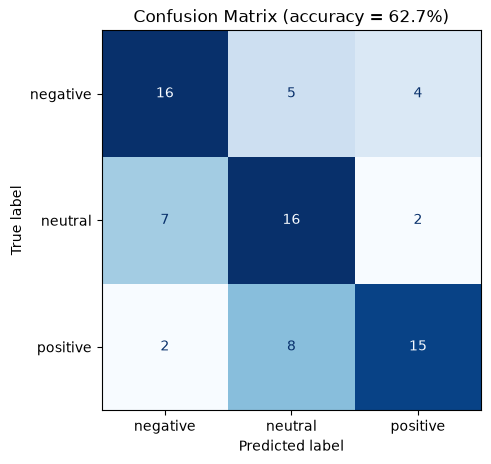

In [5]:
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.1%}")

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title(f"Confusion Matrix (accuracy = {accuracy:.1%})")
plt.tight_layout()
plt.show()

## Step 5 — Try it live: type your own tweet

This is the moment to invite the class to shout out tweet ideas. Change the text
below and re-run the cell to see the model's prediction in real time.

In [6]:
new_tweets = [
    "The flight was delayed for 4 hours and nobody told us why, so frustrating",
    "Thank you for the smooth boarding process, really appreciated it!",
    "What time does boarding start for flight 202?",
]

new_vec = vectorizer.transform(new_tweets)
predictions = model.predict(new_vec)

for tweet, pred in zip(new_tweets, predictions):
    print(f"[{pred.upper():8s}]  {tweet}")

[NEGATIVE]  The flight was delayed for 4 hours and nobody told us why, so frustrating
[POSITIVE]  Thank you for the smooth boarding process, really appreciated it!
[NEGATIVE]  What time does boarding start for flight 202?


## Talking points for the class

1. **The label is the teacher.** Every tweet came with an answer already attached —
   that's what makes this "supervised."
2. **Train/test split matters.** We only trust the accuracy number because it was
   measured on tweets the model never saw while learning.
3. **The model doesn't "understand" language.** It found statistical patterns in
   word usage (TF-IDF scores) that correlate with each sentiment label — nothing
   more mystical than that.
4. **This is exactly what brand-monitoring tools do** — scan thousands of
   mentions per day and auto-tag sentiment so a human doesn't have to read every
   single one.
5. **Bridge to the next notebook:** what if we *didn't* have those sentiment
   labels at all? That's the unsupervised learning notebook next.